R² Score: 0.979
RMSE: 37.3 casualties
MAE: 11.6 casualties


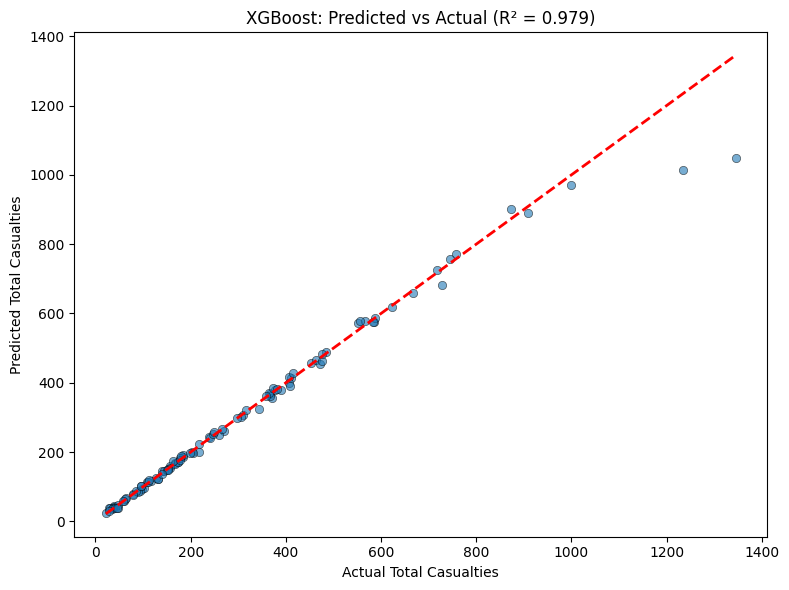

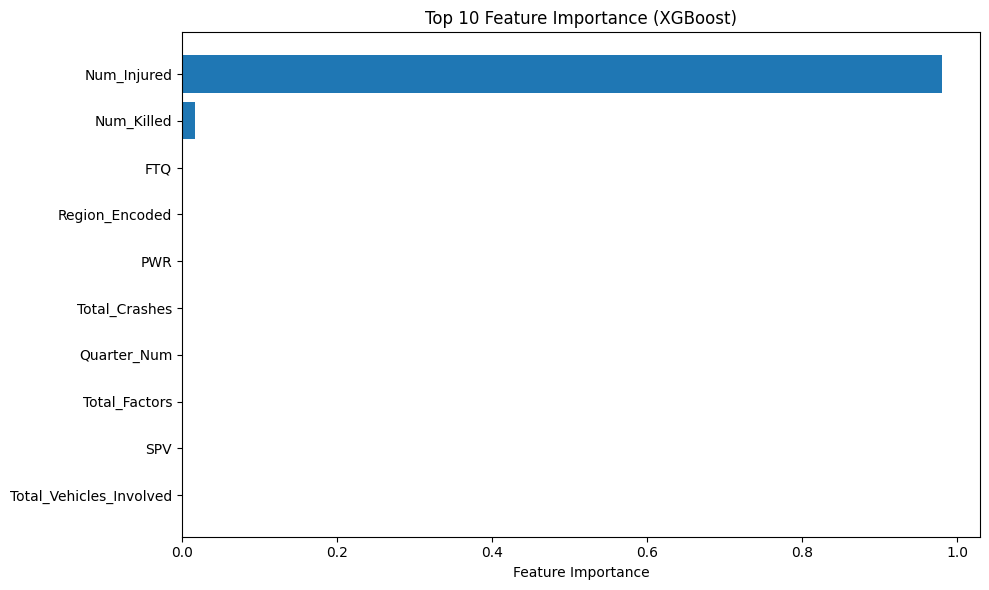

Train Score: 1.000
Test Score: 0.979


99.99998807907104 %
97.91802167892456 %


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor


df = pd.read_csv('Nigeria Crash Data P.csv')


target = 'Total_Casualties'


cols_to_drop = [
    'Quarter', 'State', 'Year', 'Quarter_Date',
    'Total_Casualties',
    'Casualty_Rate', 'Fatality_Rate', 'Vehicles_per_Crash',
    'Severe_Crash', 'High_Casualty',
    'SPV_Prop', 'DAD_Prop', 'PWR_Prop', 'FTQ_Prop', 'Other_Factors_Prop',
    'State_Encoded',
    'Region',
]


feature_cols = [col for col in df.columns if col not in cols_to_drop and col != target]


X = df[feature_cols]
y = df[target]


X = X.select_dtypes(include=[np.number])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(random_state=42, verbosity=0, enable_categorical=False)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.1f} casualties")
print(f"MAE: {mae:.1f} casualties")


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Total Casualties')
plt.ylabel('Predicted Total Casualties')
plt.title(f'XGBoost: Predicted vs Actual (R² = {r2:.3f})')
plt.tight_layout()
plt.savefig('pred_vs_actual.png', dpi=150)
plt.show()


importance = model.feature_importances_
indices = np.argsort(importance)[::-1][:10]  # top 10
top_features = [X.columns[i] for i in indices]
top_importance = importance[indices]

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), top_importance[::-1], align='center')
plt.yticks(range(len(top_features)), top_features[::-1])
plt.xlabel('Feature Importance')
plt.title('Top 10 Feature Importance (XGBoost)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
Train_Score = model.score(X_train, y_train)
Test_Score = model.score(X_test, y_test)
print(f"Train Score: {Train_Score:.3f}")
print(f"Test Score: {Test_Score:.3f}")



print("\n")
Train_Score = model.score(X_train, y_train)
Test_Score = model.score(X_test, y_test)
print(Train_Score * 100 , "%")
print(Test_Score * 100 , "%")